## Escolha de Modelos em Machine Learning

A escolha de modelo (*model selection*) é um processo iterativo que equilibra:
- viés (bias);
- variância (variance);
- interpretabilidade;
- custo computacional, e;
- requisitos do negócio.

### Conceito

A *Model Selection and Evaluation* do scikit-learn trata da seleção de modelos como um processo que envolve:

- Avaliar o desempenho real de estimadores (generalização);
- Evitar **overfitting** (alta variância);
- Controlar o **tradeoff bias-variance**.
- Escolher hiperparâmetros de forma honesta (sem *data leakage*).

O objetivo central é estimar o **erro de generalização** (performance em dados não vistos) de forma confiável, em vez de confiar em uma única divisão train/test.

**Motivação estatística:** Uma única divisão train/test pode ser otimista ou pessimista por acaso (efeito da regressão para a média que vimos na aula anterior). A validação cruzada e as curvas de validação corrigem isso.

### Cross-validation

A validação cruzada (**cross-validation**) é o pilar da model selection. Ela divide os dados em múltiplos *folds* e avalia o modelo em cada combinação treino/validação.

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# 1. Divisão hold-out final (muito importante!)
X, y = load_breast_cancer(return_X_y=True)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# 2. Definir pipeline e grade de busca
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])

# 3. Cria o Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) ## Best practice

# 4. Define os parâmetros que serão testados pelo modelo, no caso o RandomForest
param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [5, 10, 20],
    'clf__min_samples_split': [2, 5]
}

# 5. Monta uma matriz de testes para obter os melhores parâmetros para o modelo
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1 # numero de processadores em paralelo, -1 implica em todos os disponiveis
)

# 6. Encontrar melhor configuração usando CV no conjunto de treino
grid.fit(X_train_full, y_train_full)

print("Melhores hiperparâmetros:", grid.best_params_)
print("Melhor ROC AUC CV:", round(grid.best_score_, 4))

############# Produção

# 7. Treinar o modelo FINAL com TODOS os dados de treino + melhores parâmetros
final_model = grid.best_estimator_
final_model.fit(X_train_full, y_train_full)   # ← aqui nasce o modelo de produção, treinando novamente com o melhor modelo

# 8. Avaliação honesta (só agora!)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]
print("ROC AUC no teste final:", round(roc_auc_score(y_test, y_pred_proba), 4))

Melhores hiperparâmetros: {'clf__max_depth': 10, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Melhor ROC AUC CV: 0.9923
ROC AUC no teste final: 0.9931


Cada fold é uma “medição” independente. Se o modelo teve um score extremo em um fold por acaso, a média dos folds “regressa para a média” real, dando uma estimativa mais estável.

**Melhor prática (documentação)**: Sempre use `shuffle=True` (exceto em dados temporais) para evitar viés de ordenação

### Resumo

Passos recomendados para escolha de modelos:

1. Defina o problema claramente:
    - Regressão (prever valor contínuo) ou Classificação?
    - Métrica principal: RMSE/MAE (regressão), Accuracy/F1/AUC (classificação), ou métrica de negócio.
    - Restrições: interpretabilidade, tempo de inferência, tamanho do dataset.

1. Comece sempre com baselines simples:
    - Regressão: LinearRegression, DummyRegressor (média).
    - Classificação: LogisticRegression, DummyClassifier.
    - Por quê? Eles são rápidos, interpretáveis e servem de referência.

1. Considere a natureza dos dados:
    - Poucos dados + linearidade → Modelos lineares (Linear/Ridge/Lasso Regression).
    - Dados não-lineares ou interações complexas → Árvores (DecisionTree, RandomForest, XGBoost), SVM, Redes Neurais.
    - Alta dimensionalidade → Regularização (Ridge, Lasso) ou redução de dimensionalidade (PCA).
    - Dados sequenciais/temporais → Modelos de série temporal ou RNN/LSTM/Transformers.

1. Critérios de comparação:
    - Performance em validação cruzada (cross-validation) → evita overfitting.
    - Complexidade (número de parâmetros, tempo de treino).
    - Interpretabilidade (SHAP, coeficientes vs. black-box).
    - Robustez a ruído e outliers.

## Regressão para a Média

A **regressão para a média** é um fenômeno estatístico no qual valores extremos (muito acima ou abaixo da média) em uma variável aleatória tendem a ser seguidos por valores mais próximos da média em medições subsequentes.

Isso ocorre devido à variação aleatória (ruído) e à correlação imperfeita entre medições repetidas. Não é causalidade — é pura probabilidade.

### Matematicamente

Sejam $X$ e $Y$ duas variáveis com correlação $\rho < 1$ (imperfeita). O valor esperado de $Y$ dado que $X$ é extremo (ex: $X = \mu + 2\sigma$) será:

$E[Y|X_{extremo}] = Y_{\mu} + \rho (X - X_\mu)$

Como $|\rho| < 1$, o desvio de $Y$ é menor que o de $X$ $\implies$ "regressão" para a média.

### Exemplos clássicos

- Altura de pais e filhos [(Galton, 1886)](https://galton.org/essays/1880-1889/galton-1886-jaigi-regression-stature.pdf): pais muito altos têm filhos altos, mas mais próximos da média populacional;

- Notas de provas: aluno que tira 10 (extremo) na primeira prova tende a tirar menos na segunda (mesmo sem mudança de esforço) por causa do ruído (dia bom/mau, questões aleatórias);

- Medicina: pacientes com pressão arterial muito alta tendem a melhorar um pouco na próxima medição, mesmo sem tratamento;

- Esportes: [“maldição da capa da Sports Illustrated”](https://en.wikipedia.org/wiki/Sports_Illustrated_cover_jinx) — atletas em pico de performance (extremo) tendem a piorar depois.

### Armadilhas em Machine Learning e Ciência de Dados

- Interpretação causal errada: “O tratamento funcionou” quando na verdade foi só regressão para a média.
- Em avaliação de modelos: Se você seleciona apenas os casos onde o modelo errou muito (extremos negativos), na próxima avaliação eles “melhoram” naturalmente.
- Em A/B testing ou experimentos: Grupos selecionados por performance extrema no baseline mostram “melhora” espontânea.
- Em previsão: Modelos que preveem extremos com muita confiança podem sofrer de overfitting ao ruído; a regressão para a média ajuda a lembrar que previsões extremas são menos confiáveis.

### Como lidar

- Sempre use controles ou grupos de comparação.
- Meça correlação entre medições repetidas.
- Em ML: Use regularização, ensembles e cross-validation para não capturar apenas ruído.
- Visualize: scatter plot de duas medições + linha de regressão (slope < 1 indica regressão para a média).

### Ilustração

Média score1 (extremos): 132.6
Média score2 (mesmos): 122.2
Média geral score2: 100.3


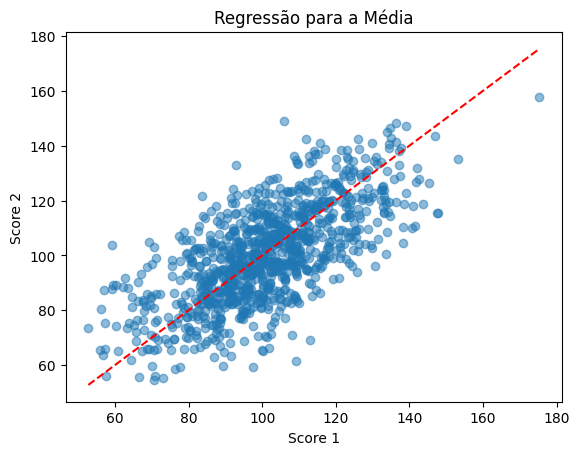

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 1000
true_skill = np.random.normal(100, 15, n)  # habilidade real
noise1 = np.random.normal(0, 10, n)
noise2 = np.random.normal(0, 10, n)

score1 = true_skill + noise1
score2 = true_skill + noise2

# Selecionar extremos na primeira medição
extremos = score1 > np.percentile(score1, 90)  # top 10%

print(f"Média score1 (extremos): {score1[extremos].mean():.1f}")
print(f"Média score2 (mesmos): {score2[extremos].mean():.1f}")
print(f"Média geral score2: {score2.mean():.1f}")

plt.scatter(score1, score2, alpha=0.5)
plt.xlabel("Score 1")
plt.ylabel("Score 2")
plt.title("Regressão para a Média")
plt.plot([min(score1), max(score1)], [min(score1), max(score1)], 'r--')  # linha y=x
plt.show()

## Tuning de Hiperparâmetros com GridSearchCV

O [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) é uma ferramenta que testa diversas configurações de parâmetros para o modelo, busca otimizar a função

Shape dos dados: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']
Treino: 112 amostras
Teste : 38 amostras
Total de combinações: 108
Iniciando GridSearchCV...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_

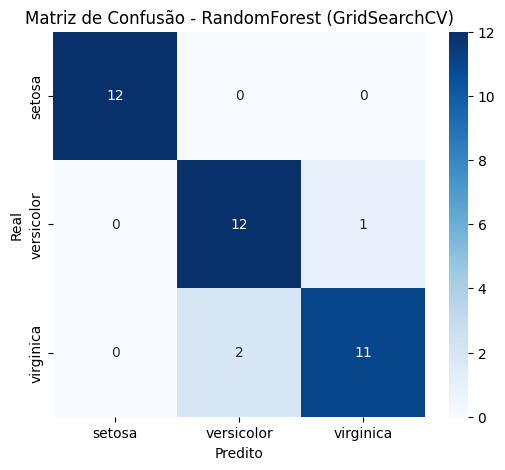

In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# =============================================
# 1. Carregando o dataset Iris
# =============================================
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f"Shape dos dados: {X.shape}")
print(f"Classes: {target_names}")

# =============================================
# 2. Divisão treino/teste (hold-out)
# =============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste : {X_test.shape[0]} amostras")

# =============================================
# 3. Definindo o espaço de busca de hiperparâmetros
# =============================================
param_grid = {
    'n_estimators': [50, 100, 200],           # número de árvores
    'max_depth': [None, 10, 15, 20],          # profundidade máxima
    'min_samples_split': [2, 5, 10],          # mínimo de amostras para split
    'min_samples_leaf': [1, 2, 4],            # mínimo de amostras na folha
    # 'max_features': ['sqrt', 'log2', None],   # features consideradas em cada split
    # 'bootstrap': [True, False]
}

print(f"Total de combinações: {np.prod([len(v) for v in param_grid.values()])}")

# =============================================
# 4. Criando o GridSearchCV
# =============================================
rf = RandomForestClassifier(random_state=42)

# Usamos StratifiedKFold para manter a proporção das classes
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',      # ou 'f1_macro' para mais robustez
    n_jobs=-1,               # usa todos os núcleos do processador
    verbose=2,               # mostra progresso
    refit=True               # refita o melhor modelo com todos os dados de treino
)

# =============================================
# 5. Executando a busca
# =============================================
print("Iniciando GridSearchCV...")
grid_search.fit(X_train, y_train)

# =============================================
# 6. Resultados da busca
# =============================================
print("\n" + "="*60)
print("MELHORES HIPERPARÂMETROS:")
print(grid_search.best_params_)
print(f"\nMelhor acurácia na validação cruzada: {grid_search.best_score_:.4f}")

# Melhor modelo já treinado
best_model = grid_search.best_estimator_

# =============================================
# 7. Avaliação no conjunto de teste (hold-out)
# =============================================
y_pred = best_model.predict(X_test)

print("\n" + "="*60)
print("DESEMPENHO NO CONJUNTO DE TESTE:")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}\n")

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - RandomForest (GridSearchCV)')
plt.show()

Também, pode ser utilizado o [RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html), que cria um espectro de busca de parâmetros randomizados.

**Recomendação oficial:** Use [RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html) quando o espaço de busca for grande (melhor que Grid para alta dimensionalidade).

Dataset Iris: 150 amostras, 4 features
Classes: ['setosa' 'versicolor' 'virginica']
Distribuição de parâmetros definida. Vamos testar 30 combinações aleatórias.

Iniciando RandomizedSearchCV com Random Forest...

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END bootstrap=True, criterion=entropy, max_depth=19, max_features=None, min_samples_leaf=5, min_samples_split=6, n_estimators=152; total time=   0.1s
[CV] END bootstrap=True, criterion=entropy, max_depth=19, max_features=None, min_samples_leaf=5, min_samples_split=6, n_estimators=152; total time=   0.1s
[CV] END bootstrap=True, criterion=entropy, max_depth=19, max_features=None, min_samples_leaf=5, min_samples_split=6, n_estimators=152; total time=   0.1s
[CV] END bootstrap=True, criterion=entropy, max_depth=19, max_features=None, min_samples_leaf=5, min_samples_split=6, n_estimators=152; total time=   0.1s
[CV] END bootstrap=True, criterion=entropy, max_depth=19, max_features=None, min_samples_leaf=5, min_samp

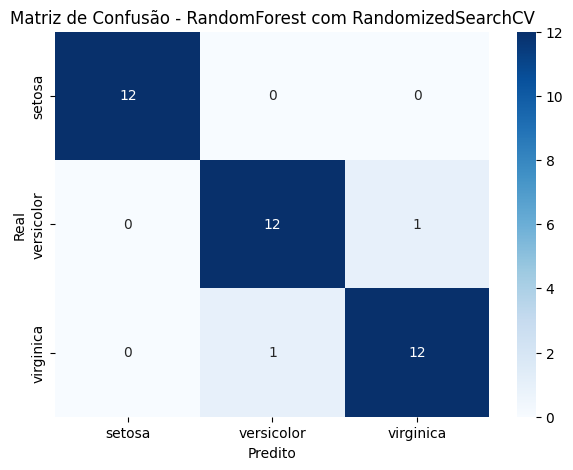

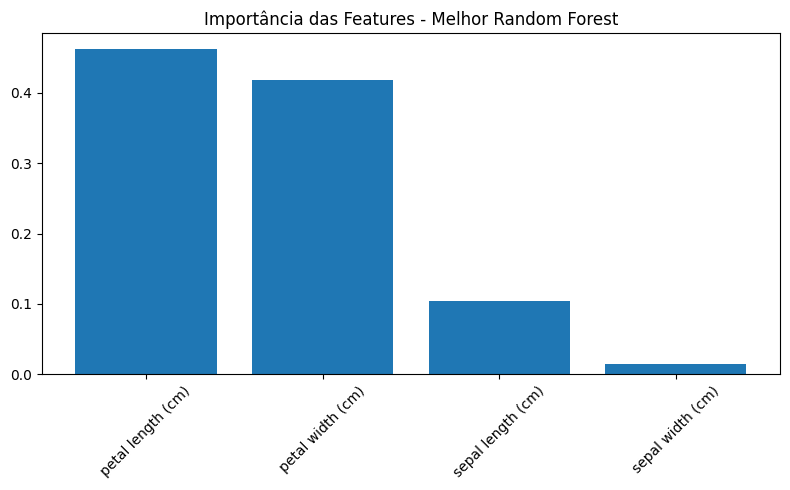

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# =============================================
# 1. Carregando os dados
# =============================================
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f"Dataset Iris: {X.shape[0]} amostras, {X.shape[1]} features")
print(f"Classes: {target_names}")

# =============================================
# 2. Divisão treino/teste
# =============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# =============================================
# 3. Definindo o espaço de distribuição de hiperparâmetros
# =============================================
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators': randint(50, 300),           # número de árvores (50 a 299)
    'max_depth': randint(5, 30),                # profundidade máxima
    'min_samples_split': randint(2, 15),        # mínimo de amostras para dividir
    'min_samples_leaf': randint(1, 8),          # mínimo de amostras na folha
    'max_features': ['sqrt', 'log2', None],     # features por split
    'bootstrap': [True, False],                 # usar bootstrap ou não
    'criterion': ['gini', 'entropy']            # critério de impureza
}

print(f"Distribuição de parâmetros definida. Vamos testar {30} combinações aleatórias.")

# =============================================
# 4. Criando o RandomizedSearchCV
# =============================================
rf = RandomForestClassifier(random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,                    # número de combinações aleatórias a testar
    cv=cv,
    scoring='accuracy',           # métrica principal
    n_jobs=-1,                    # usar todos os núcleos
    verbose=2,
    random_state=42,              # reprodutibilidade
    refit=True                    # refita o melhor modelo no final
)

# =============================================
# 5. Executando a busca
# =============================================
print("\nIniciando RandomizedSearchCV com Random Forest...\n")
random_search.fit(X_train, y_train)

# =============================================
# 6. Resultados
# =============================================
print("\n" + "="*70)
print("MELHORES HIPERPARÂMETROS ENCONTRADOS:")
for param, value in random_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\nMelhor acurácia na validação cruzada (CV): {random_search.best_score_:.4f}")

best_model = random_search.best_estimator_

# =============================================
# 7. Avaliação no conjunto de teste (hold-out)
# =============================================
y_pred = best_model.predict(X_test)

print("\n" + "="*70)
print("DESEMPENHO FINAL NO CONJUNTO DE TESTE:")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}\n")

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Matriz de Confusão - RandomForest com RandomizedSearchCV')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

# =============================================
# 8. Importância das features (bônus visual)
# =============================================
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
plt.title("Importância das Features - Melhor Random Forest")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

## Exercício

**Usando o California Housing (ou Iris):**

- Compare 3 modelos (LinearRegression / Ridge / RandomForestRegressor) usando cross_validate com 5 folds.
- Use RandomizedSearchCV com 30 iterações e compare o tempo vs. GridSearchCV, no RandomForest.
- Interprete: qual modelo tem melhor tradeoff bias-variance? Por quê?
- Faça validation_curve para o hiperparâmetro `alpha` do Ridge e `max_depth` do RandomForest.


## Referências

- [SciKit Learn - Model selection and evaluation](https://scikit-learn.org/stable/model_selection.html)
- [(Galton, 1886)](https://galton.org/essays/1880-1889/galton-1886-jaigi-regression-stature.pdf)